In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
sessions = pd.read_csv("charging_sessions.csv")
stations = pd.read_csv("charging_stations.csv")
customers = pd.read_csv("customers.csv")
districts = pd.read_csv("districts.csv")

In [5]:
sessions.head()

,session_id,customer_id,station_id,session_start_time,kwh_charged,cost_per_kwh,total_cost
0,S00001,C3806,18,2025-10-04 05:42:00,46.691971,1.851397,86.445363
1,S00002,C4931,98,2025-10-19 16:12:00,39.061716,3.256199,127.192717
2,S00003,C2250,145,2025-09-14 15:18:00,30.280525,2.704520,81.894289
3,S00004,C3790,165,2025-10-06 23:22:00,44.577079,1.851397,82.529859
4,S00005,C4834,68,2025-09-26 09:07:00,37.998209,2.704520,102.766920


In [7]:
sessions['session_start_time'] = pd.to_datetime(
    sessions['session_start_time']
)

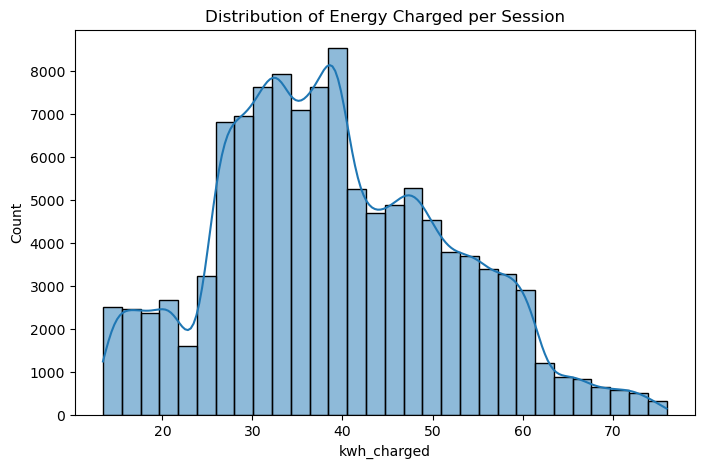

In [91]:
plt.figure(figsize=(8,5))
sns.histplot(sessions['kwh_charged'], bins=30, kde=True)
plt.title("Distribution of Energy Charged per Session")
plt.show()

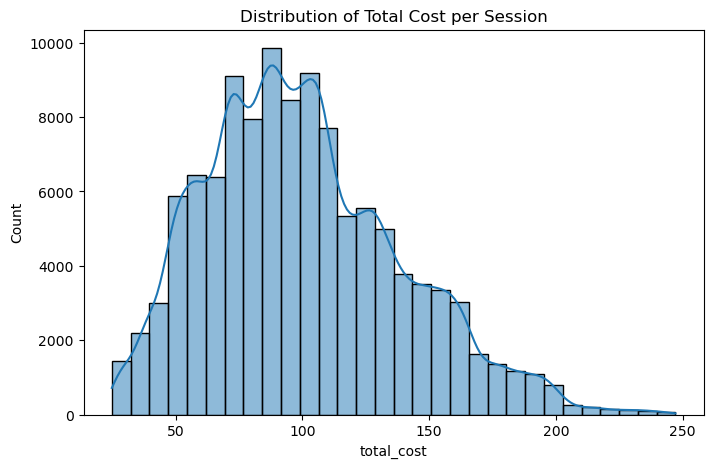

In [93]:
plt.figure(figsize=(8,5))
sns.histplot(sessions['total_cost'], bins=30, kde=True)
plt.title("Distribution of Total Cost per Session")
plt.show()

In [9]:
sessions['hour'] = sessions['session_start_time'].dt.hour
sessions['day_of_week'] = sessions['session_start_time'].dt.dayofweek
sessions['month'] = sessions['session_start_time'].dt.month

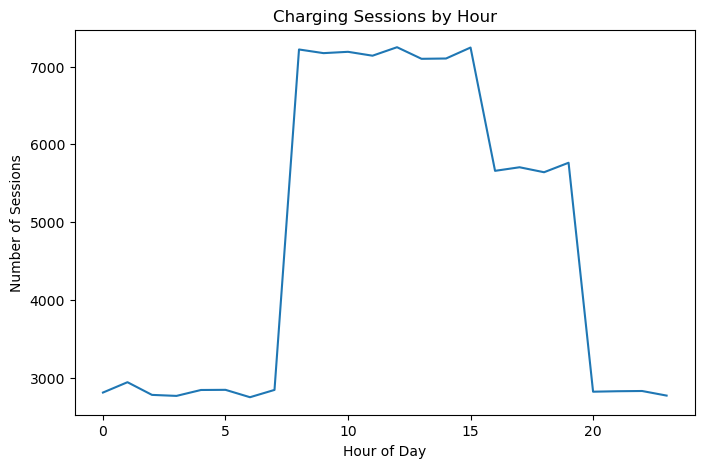

In [95]:
hourly_sessions = sessions.groupby('hour')['session_id'].count()

plt.figure(figsize=(8,5))
hourly_sessions.plot()
plt.title("Charging Sessions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Number of Sessions")
plt.show()

In [11]:
df = sessions.merge(
    stations[['station_id','district_name','plugs_count']],
    on='station_id',
    how='left'
)

In [13]:
median_kwh = df['kwh_charged'].median()

df['high_demand'] = (df['kwh_charged'] > median_kwh).astype(int)

In [15]:
df['high_demand'].value_counts()

high_demand
1    57000
0    57000
Name: count, dtype: int64

In [17]:
df = pd.get_dummies(df, columns=['district_name'], drop_first=True)

In [19]:
X = df.drop([
    'session_id',
    'customer_id',
    'session_start_time',
    'total_cost',
    'high_demand'
], axis=1)

y = df['high_demand']

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [23]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

In [25]:
from sklearn.metrics import accuracy_score, classification_report

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11418
           1       1.00      1.00      1.00     11382

    accuracy                           1.00     22800
   macro avg       1.00      1.00      1.00     22800
weighted avg       1.00      1.00      1.00     22800



In [27]:
importances = pd.Series(
    model.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

print(importances.head(10))

kwh_charged               0.991956
hour                      0.002499
station_id                0.001717
day_of_week               0.001657
month                     0.001122
cost_per_kwh              0.000302
district_name_Ursynów     0.000087
district_name_Wesoła      0.000085
district_name_Ochota      0.000072
district_name_Targówek    0.000070
dtype: float64


In [29]:
X = df.drop([
    'session_id',
    'customer_id',
    'session_start_time',
    'total_cost',
    'kwh_charged',     #  Removing This
    'high_demand'
], axis=1)

y = df['high_demand']

In [31]:
from sklearn.metrics import accuracy_score, classification_report

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print(classification_report(y_test, pred))

Accuracy: 1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11418
           1       1.00      1.00      1.00     11382

    accuracy                           1.00     22800
   macro avg       1.00      1.00      1.00     22800
weighted avg       1.00      1.00      1.00     22800



In [33]:
print(X.columns)

Index(['station_id', 'cost_per_kwh', 'hour', 'day_of_week', 'month',
       'plugs_count', 'district_name_Mokotów', 'district_name_Ochota',
       'district_name_Rembertów', 'district_name_Targówek',
       'district_name_Ursus', 'district_name_Ursynów', 'district_name_Wesoła',
       'district_name_Wilanów', 'district_name_Wola', 'district_name_Włochy',
       'district_name_Śródmieście', 'district_name_Żoliborz'],
      dtype='object')


In [35]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))

Accuracy: 0.5031140350877193


In [37]:
sessions['date'] = sessions['session_start_time'].dt.date

daily_station = sessions.groupby(
    ['station_id','date']
).agg({
    'session_id':'count',
    'kwh_charged':'sum',
    'total_cost':'sum'
}).reset_index()

daily_station.rename(columns={
    'session_id':'daily_sessions'
}, inplace=True)

In [41]:
sessions['date'] = sessions['session_start_time'].dt.date

In [43]:
daily_station = sessions.groupby(
    ['station_id', 'date']
).agg({
    'session_id': 'count',
    'kwh_charged': 'sum',
    'total_cost': 'sum'
}).reset_index()

daily_station.rename(columns={
    'session_id': 'daily_sessions'
}, inplace=True)

In [45]:
daily_station.head()

,station_id,date,daily_sessions,kwh_charged,total_cost
0,1,2025-08-11,25,950.469999,2553.343747
1,1,2025-08-12,24,964.510907,2505.147349
2,1,2025-08-13,23,845.027640,1957.150631
3,1,2025-08-14,18,644.625792,1807.097572
4,1,2025-08-15,18,736.500991,1734.528348


In [47]:
daily_station['date'] = pd.to_datetime(daily_station['date'])

In [49]:
daily_station.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5850 entries, 0 to 5849
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   station_id      5850 non-null   int64         
 1   date            5850 non-null   datetime64[ns]
 2   daily_sessions  5850 non-null   int64         
 3   kwh_charged     5850 non-null   float64       
 4   total_cost      5850 non-null   float64       
dtypes: datetime64[ns](1), float64(2), int64(2)
memory usage: 228.6 KB


In [51]:
daily_station['day_of_week'] = daily_station['date'].dt.dayofweek
daily_station['month'] = daily_station['date'].dt.month
daily_station['day'] = daily_station['date'].dt.day

In [53]:
daily_station = daily_station.merge(
    stations[['station_id','plugs_count','district_name']],
    on='station_id',
    how='left'
)

In [55]:
daily_station.head()

,station_id,date,daily_sessions,kwh_charged,total_cost,day_of_week,month,day,plugs_count,district_name
0,1,2025-08-11,25,950.469999,2553.343747,0,8,11,6,Ursynów
1,1,2025-08-12,24,964.510907,2505.147349,1,8,12,6,Ursynów
2,1,2025-08-13,23,845.027640,1957.150631,2,8,13,6,Ursynów
3,1,2025-08-14,18,644.625792,1807.097572,3,8,14,6,Ursynów
4,1,2025-08-15,18,736.500991,1734.528348,4,8,15,6,Ursynów


In [57]:
daily_station = pd.get_dummies(
    daily_station,
    columns=['district_name'],
    drop_first=True
)

In [59]:
X = daily_station.drop([
    'date',
    'daily_sessions'
], axis=1)

y = daily_station['daily_sessions']

In [61]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [63]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, r2_score

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, pred))
print("R2 Score:", r2_score(y_test, pred))

MAE: 1.1424871794871796
R2 Score: 0.8959205580105933


In [ ]:
# Clustering

In [65]:
customer_summary = sessions.groupby('customer_id').agg({
    'session_id': 'count',
    'kwh_charged': 'sum',
    'total_cost': 'sum'
}).reset_index()

customer_summary.rename(columns={
    'session_id': 'total_sessions',
    'kwh_charged': 'total_energy',
    'total_cost': 'total_spent'
}, inplace=True)

customer_summary.head()

,customer_id,total_sessions,total_energy,total_spent
0,C0001,19,960.173651,2422.408185
1,C0002,18,854.661415,2339.690348
2,C0003,17,711.942445,1910.291515
3,C0004,17,1049.066518,2730.067991
4,C0005,15,824.186706,2138.146112


In [67]:
customer_summary['avg_energy_per_session'] = (
    customer_summary['total_energy'] /
    customer_summary['total_sessions']
)

customer_summary['avg_spent_per_session'] = (
    customer_summary['total_spent'] /
    customer_summary['total_sessions']
)

In [69]:
from sklearn.preprocessing import StandardScaler

features = customer_summary.drop('customer_id', axis=1)

scaler = StandardScaler()
scaled_features = scaler.fit_transform(features)

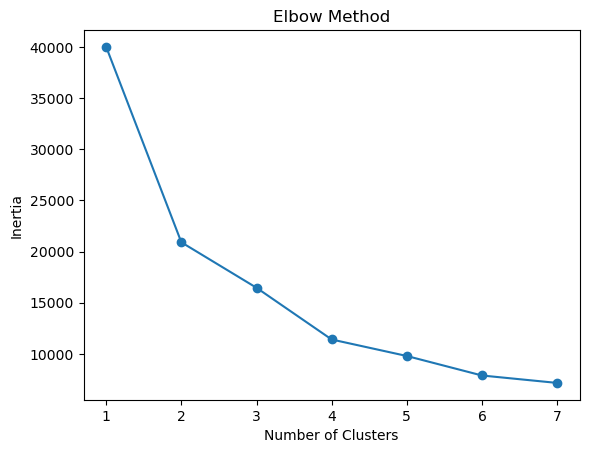

In [71]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1, 8):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(scaled_features)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 8), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [73]:
kmeans = KMeans(n_clusters=3, random_state=42)
customer_summary['cluster'] = kmeans.fit_predict(scaled_features)

customer_summary.head()

,customer_id,total_sessions,total_energy,total_spent,avg_energy_per_session,avg_spent_per_session,cluster
0,C0001,19,960.173651,2422.408185,50.535455,127.495168,1
1,C0002,18,854.661415,2339.690348,47.481190,129.982797,1
2,C0003,17,711.942445,1910.291515,41.878967,112.370089,1
3,C0004,17,1049.066518,2730.067991,61.709795,160.592235,1
4,C0005,15,824.186706,2138.146112,54.945780,142.543074,1


In [77]:
cluster_analysis = customer_summary.groupby('cluster').mean(numeric_only=True)

cluster_analysis

,total_sessions,total_energy,total_spent,avg_energy_per_session,avg_spent_per_session
cluster,,,,,
0,17.085884,564.853966,1446.388183,33.450854,85.689232
1,15.043964,771.440688,1981.527657,51.583368,132.562887
2,11.369440,343.922149,875.653550,31.218739,79.497673


In [79]:
customer_summary['cluster'].value_counts() # looks balanced

cluster
2    2945
1    2866
0    2189
Name: count, dtype: int64

In [81]:
cluster_analysis = customer_summary.groupby('cluster').mean(numeric_only=True)
cluster_analysis

,total_sessions,total_energy,total_spent,avg_energy_per_session,avg_spent_per_session
cluster,,,,,
0,17.085884,564.853966,1446.388183,33.450854,85.689232
1,15.043964,771.440688,1981.527657,51.583368,132.562887
2,11.369440,343.922149,875.653550,31.218739,79.497673


 Cluster                                                                                

Cluster 1 High-Value Power Users   High energy consumption, highest spending, strong revenue contribution 

Cluster 0 Frequent Standard Users    Most frequent chargers with moderate spend per session        

Cluster 2  Occasional Low-Usage Users  Low engagement, lowest energy and revenue contribution        


##### Customer segmentation revealed three distinct behavioral groups: high-value power users, frequent standard users, and occasional low-usage customers. The analysis highlights revenue concentration among heavy users and untapped growth potential among low-engagement segments, enabling targeted pricing, retention strategies, and infrastructure optimization.

In [99]:
Final Conclusion

This project developed a complete EV charging analytics framework including demand forecasting, regression analysis, and customer segmentation.

The demand forecasting model achieved an R² of 0.89, enabling accurate station-level demand planning.

Regression analysis revealed that pricing follows a deterministic structure based on energy consumption.

Customer clustering identified three behavioral segments, enabling targeted pricing and retention strategies.

The analysis provides actionable insights for infrastructure expansion, pricing optimization, and revenue growth.

SyntaxError: invalid character '²' (U+00B2) (248268378.py, line 5)